In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob as glb
from matplotlib.cm import get_cmap
from itertools import combinations

### Checking results

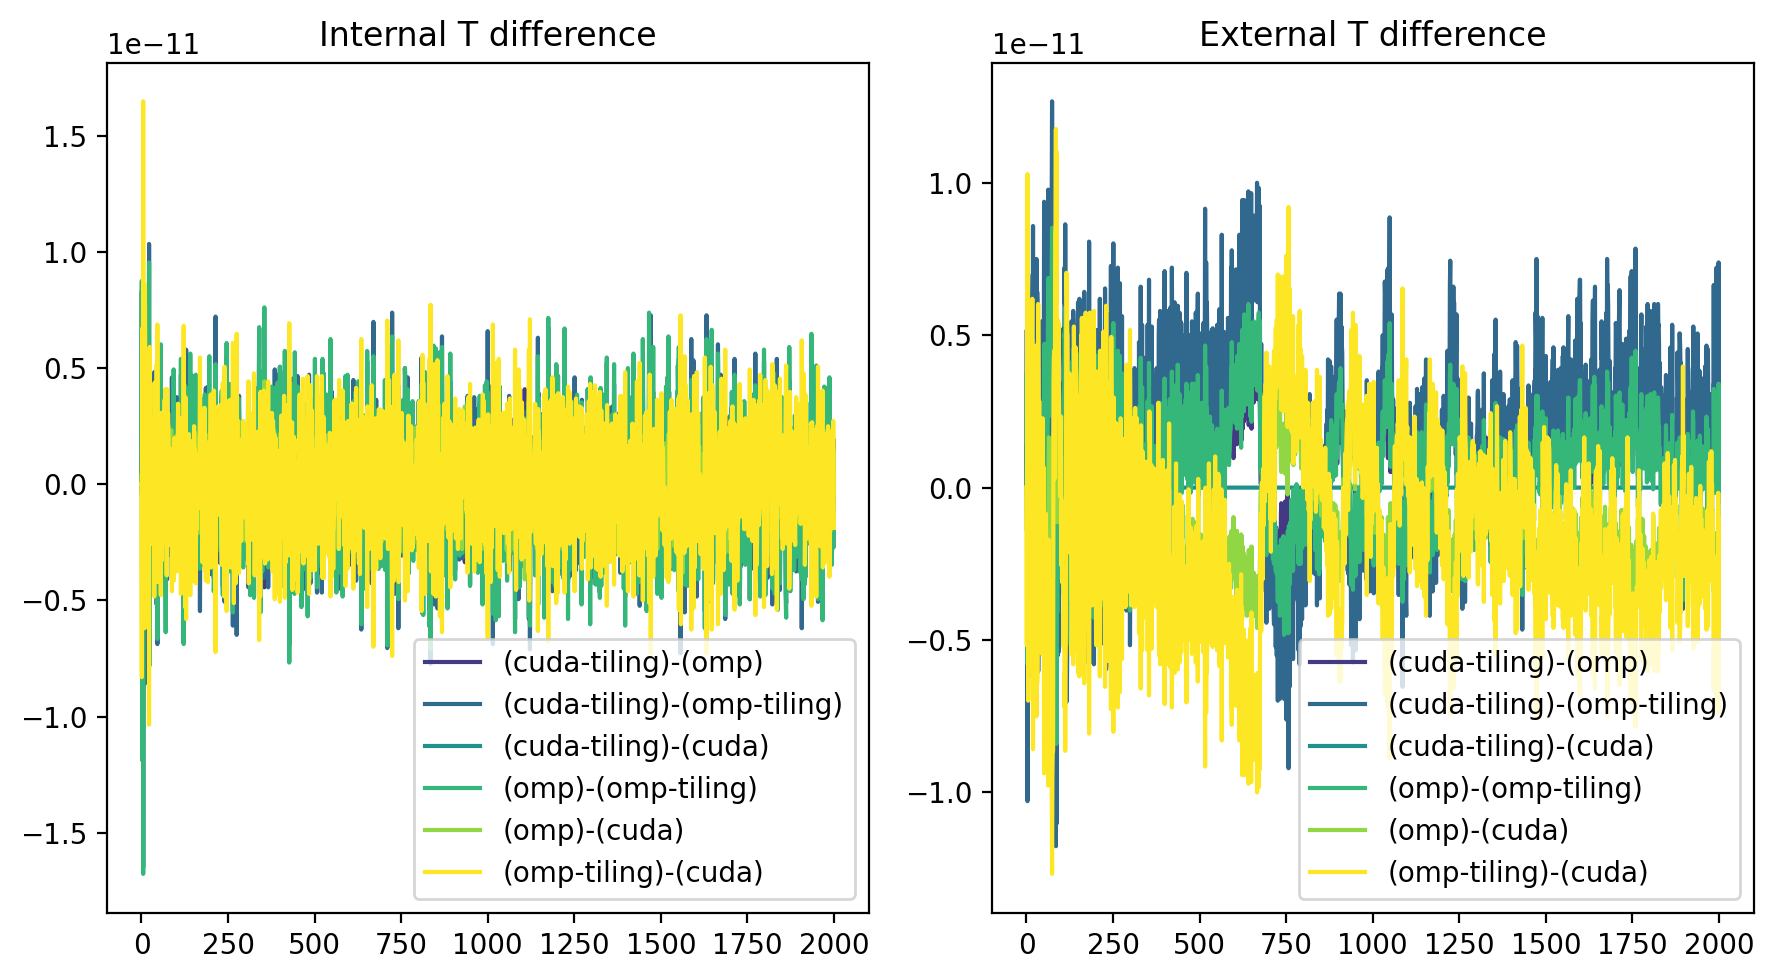

In [39]:
data_files = glb.glob("*.txt")
Nt = 2000
t_grid = np.arange(Nt+1)
Tin_dict = {df: None for df in data_files}
Tout_dict = {df: None for df in data_files}

for df in data_files:
    data = pd.read_csv(df, sep=" ")
    Tin_dict[df] = data["internal-T"].to_numpy()
    Tout_dict[df] = data["external-T"].to_numpy()

pairs = list(combinations(data_files, 2))
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(9, 5), dpi=200)
linestyle = ["o", "."]

cm = plt.get_cmap("viridis")
# plt.xlabel("Iteration")
# plt.ylabel(r"$\Delta T$")
for i, (df1, df2) in enumerate(pairs):
    clean_df1 = df1.split("-x")[0].replace("_avg_temp", "").replace("-n_threads4", "")
    clean_df2 = df2.split("-x")[0].replace("_avg_temp", "").replace("-n_threads4", "")

    ax1.plot(t_grid, Tin_dict[df1]-Tin_dict[df2], label=f"({clean_df1})-({clean_df2})", c=cm((i+1)/len(pairs)))
    ax1.set_title("Internal T difference")
    ax1.legend()

    ax2.plot(
        t_grid, Tout_dict[df1]-Tout_dict[df2], 
        label=f"({clean_df1})-({clean_df2})", 
        c=cm((i+1)/len(pairs))
        )
    ax2.set_title("External T difference")
    ax2.legend()

plt.tight_layout()

### Plotting temperatures

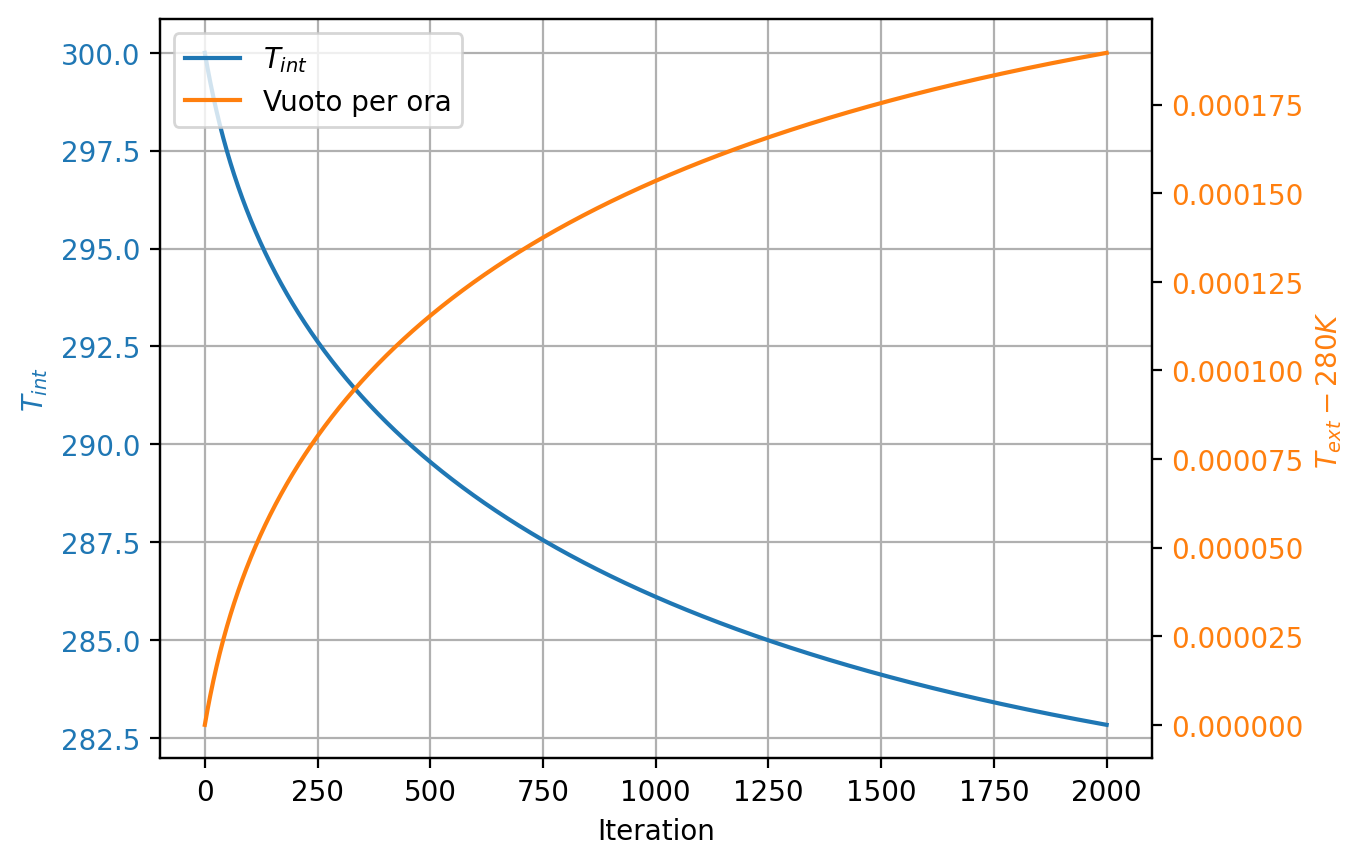

In [97]:
cuda_file = glb.glob("cuda*")[0]
# Crea la figura e il primo asse (sinistra)
fig, ax1 = plt.subplots(dpi=200)

# Primo plot sull'asse sinistro
line1 = ax1.plot(
    data["iteration"], data["internal-T"], color="tab:blue", label=r"$T_{int}$"
)
ax1.set_xlabel("Iteration")
ax1.set_ylabel(r"$T_{int}$", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Crea il secondo asse che condivide l'asse x (destra)
ax2 = ax1.twinx()

# Secondo plot sull'asse destro
T = 280
line2 = ax2.plot(
    data["iteration"],
    data["external-T"] - T,
    color="tab:orange",
    label="Vuoto per ora",
)
ax2.set_ylabel(r"$T_{ext}-280K$", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

# Legenda unica che unisce entrambe le curve
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")
ax1.grid(True)

plt.show()

### Benchmarking OMP routine

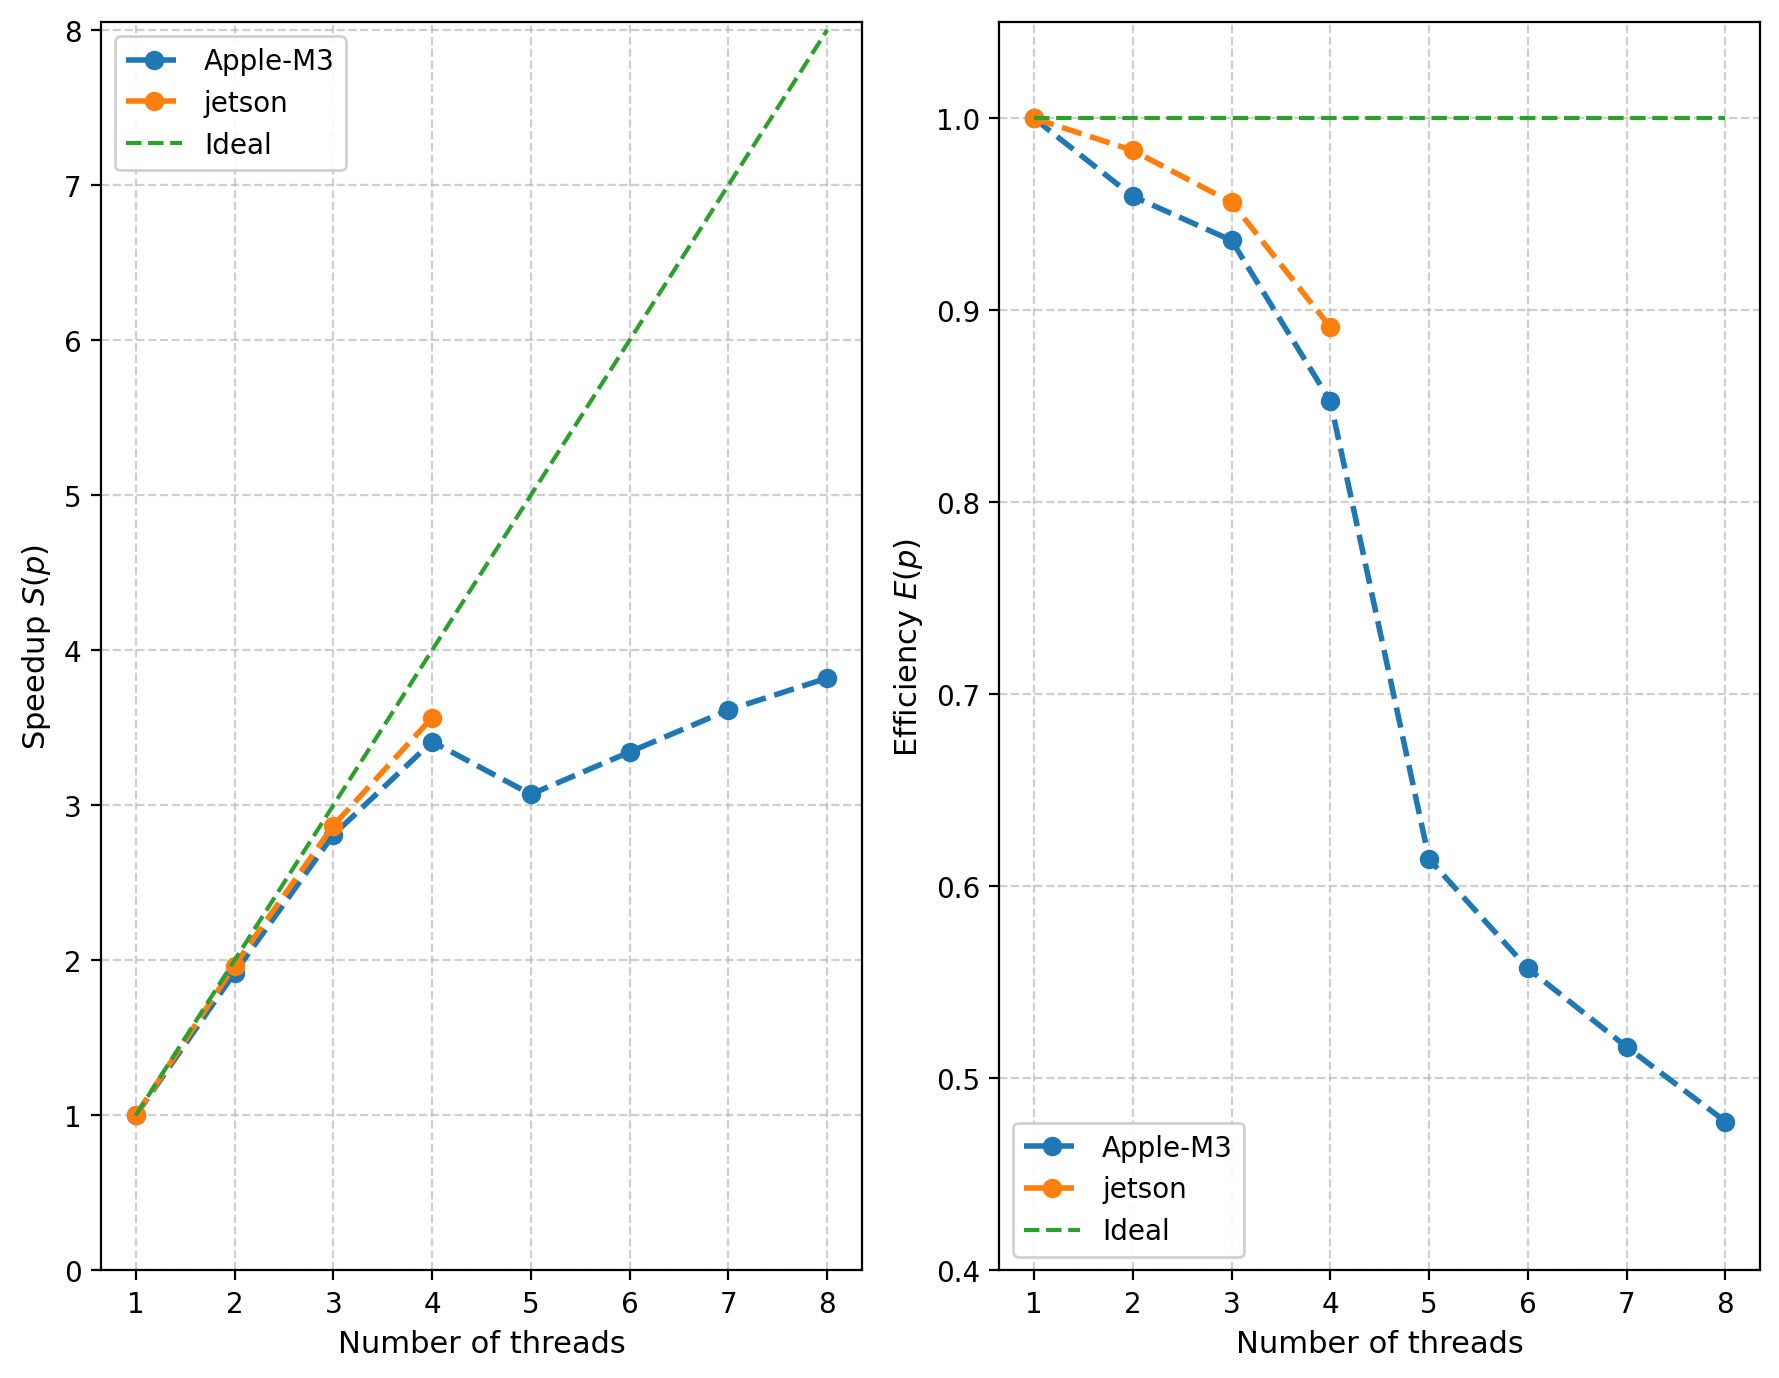

In [66]:
def nice_plot(axis, x, y, label, ls):
    axis.grid(True, linestyle="--", alpha=0.6)
    axis.plot(x, y, label=label, linestyle=ls, marker="o", linewidth=2, markersize=6)
    axis.set_xlabel("Number of threads", fontsize=11)


directories = glb.glob("thread-scaling-*")
n_threads = [4, 8]
wall_time_jet = np.zeros(n_threads[0])
wall_time_mac = np.zeros(n_threads[1])

for dir in directories:
    data_files = sorted(glb.glob(dir+"/*"))
    for i, df in enumerate(data_files):
        data = pd.read_csv(df, sep=" ")

        if dir.split("thread-scaling-")[1] == "mac":
            wall_time_mac[i] = data["elapsed-time"].iloc[-1]
        else:
            wall_time_jet[i] = data["elapsed-time"].iloc[-1]

fig, axes = plt.subplots(ncols=2, figsize=(9,7), dpi=200)
wall_time = [wall_time_mac, wall_time_jet]
for name, n_thr, wt in zip(("Apple-M3", "jetson"), (8, 4), wall_time):
    # Plot 1: speedup
    speedup = wt[0]/wt
    thr_num = np.arange(n_thr)+1
    nice_plot(axes[0], thr_num, speedup, f"{name}", "--")
    

    # Plot 2: efficiency
    efficiency = speedup/thr_num
    nice_plot(axes[1], thr_num, efficiency, f"{name}", "--")

thr_range = np.arange(1, 9)
axes[0].plot(thr_range, thr_range, label="Ideal", ls="--")
axes[0].set_ylabel("Speedup $S(p)$", fontsize=11)
axes[0].set_ylim(0, 8.05)
axes[0].legend(frameon=True, facecolor="white", framealpha=0.9)

axes[1].set_ylabel("Efficiency $E(p)$", fontsize=11)
axes[1].set_ylim(0.4, 1.05)  # L'efficienza teorica sta tra 0 e 1
axes[1].plot(thr_range, [1]*8, label="Ideal", ls="--")
axes[1].legend(frameon=True, facecolor="white", framealpha=0.9)

axes[0].set_xticks(np.arange(1, 9))
axes[1].set_xticks(np.arange(1, 9))

plt.tight_layout()


### Benchmarking GPU

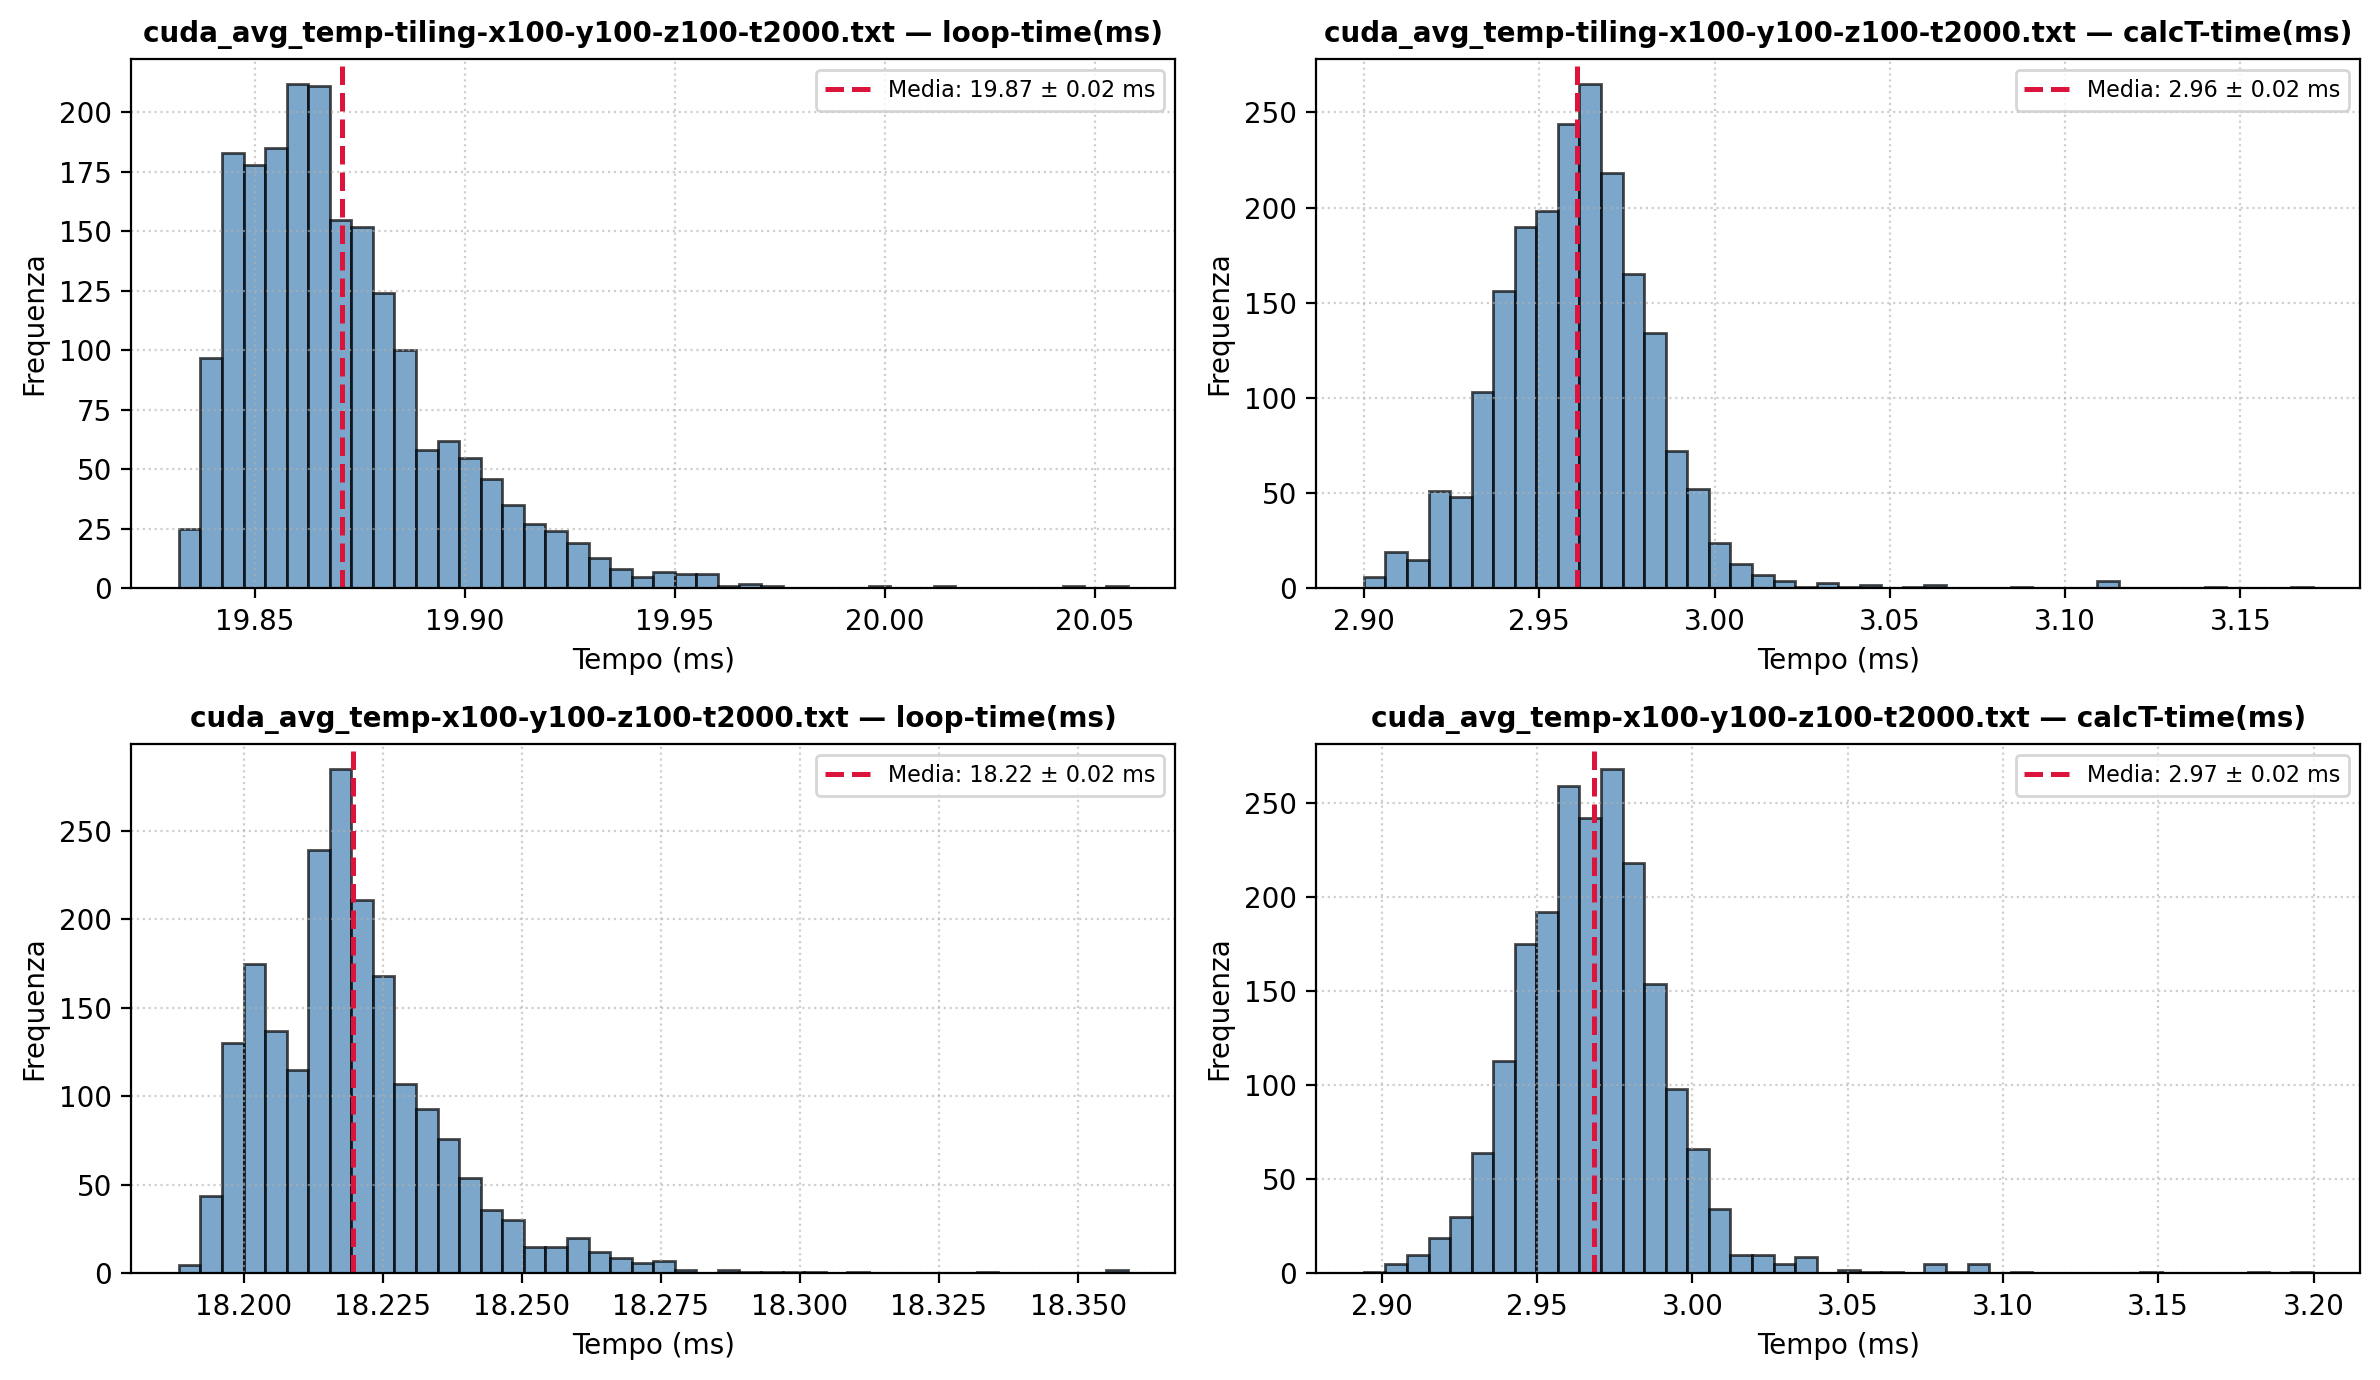

In [91]:
data_files = glb.glob("cuda_avg_temp*")
fields = ["loop-time(ms)", "calcT-time(ms)"]

# Crea una griglia: 1 riga per file, 2 colonne (1 per ciascuna metrica)
fig, axes = plt.subplots(
    nrows=len(data_files), 
    ncols=2, 
    dpi=200, 
    figsize=(12, 3.5 * len(data_files)),
    sharey=False
)

# Gestisce il caso in cui ci sia un solo file (axes diventa 1D)
if len(data_files) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, df in enumerate(data_files):
    data = pd.read_csv(df, sep=r"\s+") # Usato \s+ per gestire spazi multipli

    for j, field in enumerate(fields):
        ax = axes[i, j]
        time_data = data[field]
        
        mean_val = np.mean(time_data)
        std_val = np.std(time_data)
        n_bins = int(np.sqrt(len(time_data)))

        # Istogramma
        counts, _, _ = ax.hist(time_data, bins=n_bins, alpha=0.7, edgecolor='black', color='steelblue')
        
        # Linea della media con deviazione standard nella legenda
        ax.axvline(
            mean_val, 
            color='crimson', 
            linestyle='--', 
            linewidth=1.8, 
            label=f'Media: {mean_val:.2f} ± {std_val:.2f} ms'
        )

        # Restyling grafico
        ax.set_title(f"{df} — {field}", fontsize=10, fontweight='bold')
        ax.set_xlabel("Tempo (ms)")
        ax.set_ylabel("Frequenza")
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()